# Compute GLORYs EOFs
## Created by Dani Lafarga 7/15/2024
## Last edited on 12/6/2024
Program has various functions that will read in raw GLORYS data and compute climatologies and anomalies 
To change the code to a different data set change the first three functions to read in your desired data
by changing the directory and variable name. 

This is specified for climate data and will need latitude, longitude, and depth variables to run. This means all files saved and all climatologies and anomalies will be 3D arrays. 

**ALL SAVED FILES WILL HAVE WEIGHTED VARIABLES!(Excepth Standard deviation)**

The following outlines all sections of code:

- Section 1 will define all functions to run the later calculations

- Section 2 will compute climatologies and anomalies for one month

- Section 3 will compute climatologies and anomalies for a seasonal average

- Section 4 will compute running 3 months

# Section 1: All functions

In [1]:
import numpy as np
from numpy import meshgrid
import scipy.io as sc
import os
from pprint import pprint
import matplotlib.pyplot as plt
import scipy.linalg as la
import pandas as pd
from numpy import linspace
from numpy import meshgrid
from mpl_toolkits.basemap import Basemap
import matplotlib as mpl
import matplotlib
import math

import netCDF4 as nc 
from netCDF4 import Dataset as ds

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
top2    = cm.get_cmap('winter')
bottom2 = cm.get_cmap('hot_r')
newcolors2 = np.vstack((top2(np.linspace(0, 1, 128)),   # I want all of the winter cmap and it will only explain 100 points
                    bottom2(np.linspace(.1, .9, 128)))) # I dont want the extremes of hot cmap but it will explain 128 points
newcmp2 = ListedColormap(newcolors2, name='OrangeBlue')


#################################################################################################################
#################################################################################################################
def set_directory():
    global data_directory
    path = 'F:/GLORYS/'
    if not os.path.exists(path):
        data_directory = '/Volumes/Elements/GLORYS'
    else:
        data_directory = path
    return



# def output_directory():
#     global anomalies_directory
#     path = 'F:/GLORYS/Anomalies"
#     if not os.path.exists(path):
#         data_directory = '/Volumes/Elements/GLORYS'
#     else:
#         data_directory = path
#     return



#################################################################################################################
#################################################################################################################
# Function get_var() will get common variables that will be required for climatologies,
# anomalies, and EOFs
# Input: 
#         - MON_INDEX: int month index tells us home many years we will have 
#              Months 1-6 have 29 years
#              Months 7-12 only have 28 years
# Output: 
#         - lat: 1d array with all latitude values
#         - lon: 1d array with all longitude values
#         - depth: 1d array with all depth values
#         - years: 1d array with all year values
def get_var(MON_INDEX):
    fn     = 'thetao.mon.mean.1994.nc'
    fn     = os.path.join(data_directory, fn)
    fn     =  ds(fn,'r')
    lat    = fn.variables['latitude'][:].data    # read in latitude
    lon    = fn.variables['longitude'][:].data   # read in longitude
    depths = fn.variables['depth'][:].data       # read in depth
    fn.close()
    if MON_INDEX > 0 and  MON_INDEX<=6:
        years  = np.linspace(1993, 2021,29, dtype="int")  # array with years for months 1-6
    elif MON_INDEX > 6 and  MON_INDEX<=12:   
        years  = np.linspace(1993, 2020,28, dtype="int")  # array with years for months 7-12
    return lat, lon, depths, years



# #################################################################################################################
# #################################################################################################################
# # Function get_var() will get common variables that will be required for climatologies,
# # anomalies, and EOFs
# # Input: 
# #         - MON_INDEX: month index tells us home many years we will have 
# #              Months 1-6 have 29 years
# #              Months 7-12 only have 28 years
# #              MON_INDEX = 0 means 3 month season
# # Output: 
# #         - lat: 1d array with all latitude values
# #         - lon: 1d array with all longitude values
# #         - depth: 1d array with all depth values
# #         - years: 1d array with all year values
# def get_var():
#     fn     = 'thetao.mon.mean.1994.nc'
#     fn     = os.path.join(data_directory, fn)
#     fn     =  ds(fn,'r')
#     lat    = fn.variables['latitude'][:].data    # read in latitude
#     lon    = fn.variables['longitude'][:].data   # read in longitude
#     depths = fn.variables['depth'][:].data       # read in depth
#     fn.close()
#     return lat, lon, depths
# #################################################################################################################
#################################################################################################################
# Function reads in raw GLORYS temperature data
# Willl need to specify the month and month index as global variables 
# NOTE: will need to change the directory to read the data
# Input:
#         - year: integer that will define which year will be read in 
#         - MON_INDEX: int index of the month read in 
# Output:
#         - var: 3D matrix of dimension (depth, lat, lon) with the variable data
#                   all land is represented by NaNs
# Important Variables: None
def read_raw_data(MON_INDEX,year):
    fn     =  'thetao.mon.mean.'+str(year)+'.nc'         # file names will differ in year
    fn     =  os.path.join(data_directory, fn)
    fn     =  ds(fn,'r')
    var = fn.variables['thetao'][MON_INDEX-1,:,:,:]      # read in temps
    var = var.astype(float)                              # Change type to change fill values to NaN
    var.set_fill_value(np.nan)                           # Change fill values to NaN so addition doesn't add int fill values
    var = var.filled()
    fn.close()
    return var
#################################################################################################################    
#################################################################################################################
# Function to compute climatologies 
# Inputs:
#         - years: a 1D array with all the years to iterate through
#         - MON_INDEX: int index of the month read in 
# Outputs:
#         - clim: climatologies for the month specified 
# Important variables:
#         - var: 3D array with ocean temperatures
#         - clim: 1D->3D array that will contain the running sum of temps and avg
def compute_Clim(MON_INDEX,years):
    lat, lon, depths, _ = get_var(MON_INDEX)
    clim = np.zeros((len(lat) * len(lon) * len(depths))) # initialize array for climatology
    for year in years:                                   # iterate through every year
        var  = read_raw_data(MON_INDEX,year)
        var  = var.flatten()            # flatten to more easily add grid points(could do without)
        clim += var                     # sum of grid point through years
    clim = clim/len(years)              # divide by total amount of years for avg
    clim = np.reshape(clim, (len(depths),lat.shape[0], lon.shape[0])) # reshape to 3D array
    # saving climatologies
    fn = month + '.mon.clim.nc'
    fn  = os.path.join(anomalies_directory, fn)
    nc0 = ds(fn, 'w', format='NETCDF4')
    save_file(nc0, depths, lat, lon, clim, 'clim')
    return clim
#################################################################################################################
#################################################################################################################
# Function computes volume weights based on latitude and depthe values. Although longitude values are not
# in the equation the length of the longitude array is necessary for building 3D volume weight array 
# Input:
#         - lat: 1d array with all latitude values
#         - lon: 1d array with all longitude values
#         - depth: 1d array with all depth values
# Output: 
#         - area_weight: 3D array
# Important variables:
#         - xx: 2D array of longitude values from 1D array lon. It is size (lat, lon)
#         - yy: 2D array of latitude values from 1D array lat. It is size (lat, lon)
#         - tot_depth: integer of the total amount of depths specified by input depth
#         - area_w: 2D array with the cosine of radian latitude values this will later be multiplied by depth layer thickness 

def vol_weight(depths, lon, lat):
    xx, yy = meshgrid(lon, lat) # create a 2D array with longitude and latitude values for one depth
    tot_depth = len(depths)     # int of the total amount of depths
    
    # area weight for lattitude values
    area_w = np.cos(yy*math.pi/180) # change latitude degrees to radians
    if lat[-1] == 90.0:             # accounting for the 0 truncation at 90 degrees          
        area_w[-1,:] = 0.0
    # area weights for depth
    area_weight = []
    for i in range(tot_depth): # for each depth
        if i == 0:             # first depth thickness is surface(0) to the first depth
            area_weight.append(np.sqrt(depths[0] * area_w)) # first depth thickness
        else:
            area_weight.append( np.sqrt((depths[i] - depths[i - 1]) * area_w))
    # Turning weights into one array
    area_weight = np.array(area_weight)
    return area_weight

#################################################################################################################
#################################################################################################################
# Function to compute anomalies and call save function
# Inputs:
#         - MON_INDEX: int index of the month read in 
#         - clim: a 3D array with climatology for all time 1993-2021
# Outputs:
#         - no specific output as the anomalies are saved to a file after calling save_file 
# Important variables:
#         - var: 3D array with ocean temperatures
def compute_anomalies_monthly(MON_INDEX,clim):
    lat, lon, depths, years = get_var(MON_INDEX)   # get common variables for weights
    weight = vol_weight(depths, lon, lat)          # volume weight
    for year in years:                             # for every year
        var  = read_raw_data(MON_INDEX,year)         # read in raw temp data for specified year
        anom = var - clim                          # compute anomalies
        anom = anom * weight                       # compute weighted anomalies
        fn   =  month +'.anom.mon.'+str(year)+'.nc'
        fn   = os.path.join(anomalies_directory, fn)
        nc0  = ds(fn, 'w', format='NETCDF4')
        save_file(nc0, depths, lat, lon, anom, 'anom')
#################################################################################################################
#################################################################################################################
# Function to save any 3D variable of size (depth, lat, lon)
# Inputs:
#         - nc0: the data file pointer to write to
#         - Z: 1d array with all depth values
#         - lat: 1d array with all latitude values
#         - lon: 1d array with all longitude values
#         - Var1: 3D array with data to save
#         - Var1_name: string with name of the varible being saved. 
# Outputs:
#         - no specific output as the variable is saved to a file in nc0 
def save_file(nc0, Z, lat, lon, Var1, Var1_name):
    nc0.createDimension('Z', len(Z))
    nc0.createDimension('Y', lat.shape[0])
    nc0.createDimension('X', lon.shape[0])

    lat_save = nc0.createVariable('lat', 'float32', ('Y'), fill_value = np.nan)
    lon_save = nc0.createVariable('lon', 'float32', ('X'), fill_value = np.nan)
    Z_save   = nc0.createVariable('Z', 'float32', 'Z', fill_value = np.nan)
    Var1_save = nc0.createVariable(Var1_name, 'f4', ('Z','Y','X'), fill_value = np.nan)

    lat_save[:]  = lat
    lon_save[:]  = lon
    Z_save [:]   = np.array(Z)
    Var1_save[:] = Var1
    
    nc0.close()
    return
import csv
#################################################################################################################
#################################################################################################################
# Function creates a folder if it doesnt already exist
# Input:
#         - folder_path: string with the path name to folder

def create_folder(folder_path):
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{folder_path}' created.")
    else:
        print(f"Folder '{folder_path}' already exists.")
#################################################################################################################
#################################################################################################################
# Function reads in raw cut anomalies
# 
# Input:
#         - MON_INDEX: int index of the month read in 
#         - year: int with the specific year to read
# Output:
#         - anom: 3D array of dim (depth, lat, lon) with the anomaly data
def read_anom_raw(MON_INDEX,year):
    month = months[MON_INDEX-1]
    fn   = month +'.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)      # join with the directory that can be changed
    nc0 = ds(fn, 'r')
    anom = nc0.variables['anom'][:, :, :]
    anom = anom.filled()
    nc0.close()
    return anom
#################################################################################################################    
#################################################################################################################
# Function to compute standard deviation
# standard deviation is not weighted
# Inputs:
#         - MON_INDEX: index of the month read in 
#         - years: a 1D array with all the years to iterate through
# Outputs:
#         - function just saves the standard deviation variable 
# Important variables:
#         - var: 3D array with ocean anomalies 
#         - sdev: 3D array that will contain the standard deviation
def compute_SDev(MON_INDEX,years):
    lat, lon, depths, _ = get_var(MON_INDEX)
    sdev = np.zeros((len(depths), len(lat),len(lon))) # initialize array 
    weight = vol_weight(depths, lon, lat)
    for year in years:                  # iterate through every year
        var  = read_anom_raw(MON_INDEX,year)
        var  = var/weight               # want raw anom not weighted
        var  = var**2
        sdev += var                     # sum of grid point through years
    sdev = sdev/len(years)              # divide by total amount of years for avg
    sdev = np.sqrt(sdev)
    # saving standard deviation
    fn = month + '.mon.sdev.nc'
    fn  = os.path.join(anomalies_directory, fn)
    nc0 = ds(fn, 'w', format='NETCDF4')
    save_file(nc0, depths, lat, lon, sdev, 'sdev')
    return 
#################################################################################################################
#################################################################################################################
# Function will plot any variable at a specified depth
#       - depth_ind: int with depth index
#       - variable: 3D array with variable to plot
#       - variable_name: string with name of variable for the plot title
def plot_variable(depth_ind, variable, variable_name):
    lat, lon, depths, _ = get_var(MON_INDEX)
    
    depth = depths[depth_ind]
    
    dat = variable[depth_ind,:,:]
    clip = np.nanmax(abs(dat)) # set min and max values
    #clip = 1
    norm = mpl.colors.Normalize(vmin=-clip, vmax=clip)
    
    title_sz = 19
    label_sz = title_sz-3
    
    #Plot first depth
    plt.subplots(figsize=(15., 7.)) 
    mymap = Basemap(projection='cyl',llcrnrlat=lat[0],urcrnrlat=lat[-1],llcrnrlon=lon[0],urcrnrlon=lon[-1],resolution='c')
    #mymap = plt.axes(projection=ccrs.PlateCarree())
    mymap.drawcoastlines(color='black', linewidth=.5)
    mymap.drawmapboundary()
    mymap.drawparallels(np.arange(lat[0],lat[-1],30), labels = [1,0,0,0], fontsize = label_sz)
    mymap.drawmeridians(np.arange(lon[0],lon[-1],45), labels = [0,0,0,1], fontsize = label_sz)
    
    plt.contourf(lon, lat,  dat, 20, cmap = 'jet')#newcmp2, norm= norm)
    if depth_ind == 0:
        plt.title(f'{month} {variable_name} GLORYs at Surface', fontsize = title_sz)
    else: 
        plt.title(f'{month} {variable_name} GLORYs at {depth} m', fontsize = title_sz)
    
    
    cbar = plt.colorbar( shrink = .83)
    cbar.ax.set_title('$^{\circ}$C',fontsize=label_sz)
    cbar.ax.tick_params(labelsize=label_sz)
    cbar.update_ticks()

<>:337: SyntaxWarning: invalid escape sequence '\c'
<>:337: SyntaxWarning: invalid escape sequence '\c'
C:\Users\bubby\AppData\Local\Temp\ipykernel_25424\2937546476.py:337: SyntaxWarning: invalid escape sequence '\c'
  cbar.ax.set_title('$^{\circ}$C',fontsize=label_sz)
C:\Users\bubby\AppData\Local\Temp\ipykernel_25424\2937546476.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  top2    = cm.get_cmap('winter')
C:\Users\bubby\AppData\Local\Temp\ipykernel_25424\2937546476.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bottom2 = cm.get_cmap('hot_r')


# Section 2: Computing Clim and Anom for one month

**Defining the directories**

In [2]:
# change month index to whatever month being worked on
MON_INDEX = 12
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug','Sep', 'Oct', 'Nov', 'Dec']
month = months[MON_INDEX-1] # string of month to define folder
# CAUTION!!! 
# variable 'month' will define the name and folder of climatologies and anomalies
# change month to another string if it is anything else
# ex: month = 'Winter Avg'
set_directory()

anomalies_directory     = os.path.join('F:/GLORYS/Anomalies/' + month)
cut_anomalies_directory = os.path.join('F:/GLORYS/Cut_Anomalies/' + month)
EOF_directory = os.path.join('F:/GLORYS/cut_EOFs/' + month)

In [29]:
create_folder(anomalies_directory)

Folder 'F:/GLORYS/Anomalies/Dec' already exists.


**Compute climatologies**

In [3]:
lat, lon, depths, years = get_var(MON_INDEX)

In [ ]:
clim = compute_Clim(MON_INDEX, years)

**Computing anomalies**

If the above is not run then read in climatology to compute anomalies

In [31]:
# read in climatologies 
fn = month + '.mon.clim.nc'
fn = os.path.join(anomalies_directory, fn)
nc0 = ds(fn, 'r')
clim = nc0.variables['clim'][:]



nc0.close()
clim.set_fill_value(np.nan)
clim = clim.filled()

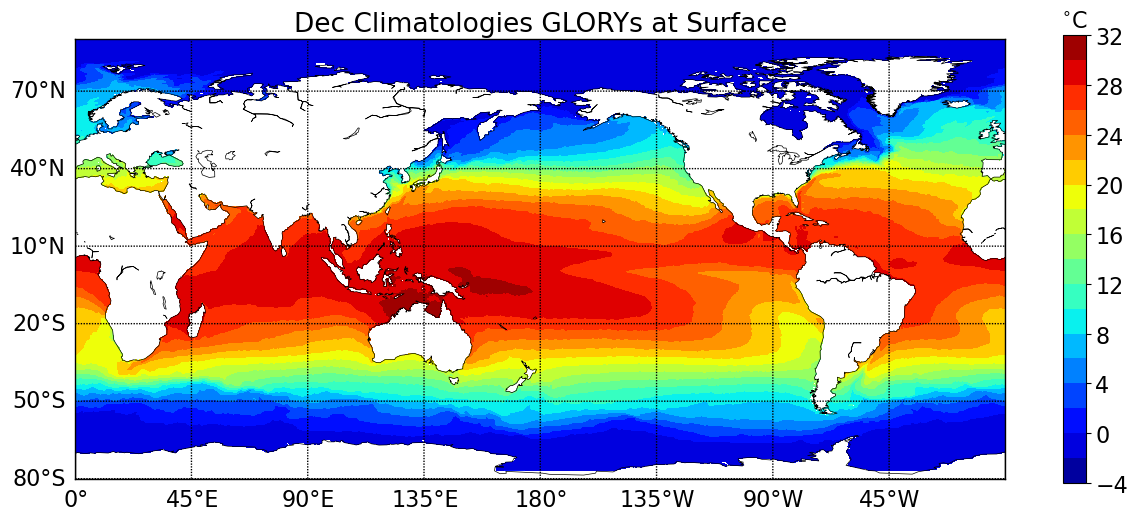

In [47]:
plot_variable(0, clim, 'Climatologies')

In [18]:
compute_anomalies_monthly(MON_INDEX, clim)

In [4]:
# read in anomalies
#fn = 'F:/GLORYS/thetao.mon.mean.2007.nc'
fn = 'F:/GLORYS/Anomalies/Winter Avg/Winter.anom.mon.1994.nc'

nc0 = ds(fn, 'r')
#anom = nc0.variables.keys()
anom = nc0.variables['anom'][:]


nc0.close()
# clim.set_fill_value(np.nan)
# clim = clim.filled()

C:\Users\bubby\AppData\Local\Temp\ipykernel_25424\2941075211.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  top2 = cm.get_cmap('winter')
C:\Users\bubby\AppData\Local\Temp\ipykernel_25424\2941075211.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bottom2 = cm.get_cmap('hot_r')


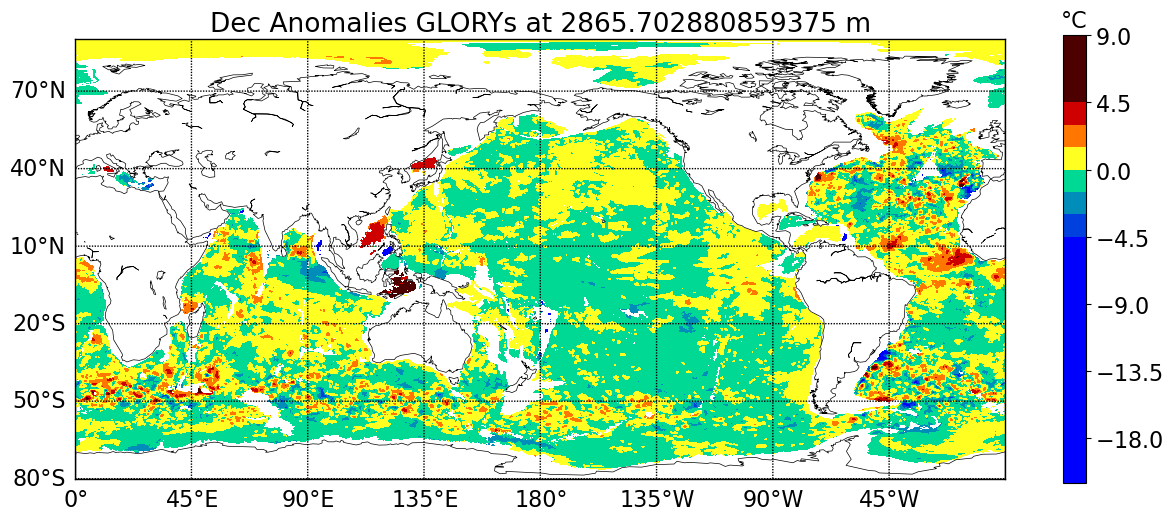

In [11]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
top2 = cm.get_cmap('winter')
bottom2 = cm.get_cmap('hot_r')
newcolors2 = np.vstack((top2(np.linspace(0, 1, 128)),   # I want all of the winter cmap and it will only explain 100 points
                    bottom2(np.linspace(.1, .9, 128)))) # I dont want the extremes of hot cmap but it will explain 128 points
newcmp2 = ListedColormap(newcolors2, name='OrangeBlue')



depth_ind = 42
variable = anom
variable_name = "Anomalies"


lat, lon, depths, _ = get_var(MON_INDEX)

depth = depths[depth_ind]

dat = variable[depth_ind,:,:]
#clip = np.nanmax(abs(dat)) # set min and max values
clip = 5
norm = mpl.colors.Normalize(vmin=-clip, vmax=clip)

title_sz = 19
label_sz = title_sz-3

#Plot first depth
plt.subplots(figsize=(15., 7.)) 
mymap = Basemap(projection='cyl',llcrnrlat=lat[0],urcrnrlat=lat[-1],llcrnrlon=lon[0],urcrnrlon=lon[-1],resolution='c')
#mymap = plt.axes(projection=ccrs.PlateCarree())
mymap.drawcoastlines(color='black', linewidth=.5)
mymap.drawmapboundary()
mymap.drawparallels(np.arange(lat[0],lat[-1],30), labels = [1,0,0,0], fontsize = label_sz)
mymap.drawmeridians(np.arange(lon[0],lon[-1],45), labels = [0,0,0,1], fontsize = label_sz)

plt.contourf(lon, lat,  dat, 20, cmap = newcmp2, norm = norm)#newcmp2, norm= norm)
if depth_ind == 0:
    plt.title(f'{month} {variable_name} GLORYs at Surface', fontsize = title_sz)
else: 
    plt.title(f'{month} {variable_name} GLORYs at {depth} m', fontsize = title_sz)


cbar = plt.colorbar(format=mpl.ticker.ScalarFormatter(useMathText=True), shrink = .83)
cbar.ax.set_title('°C',fontsize=label_sz)
cbar.ax.tick_params(labelsize=label_sz)
cbar.update_ticks()

In [51]:
clip

1

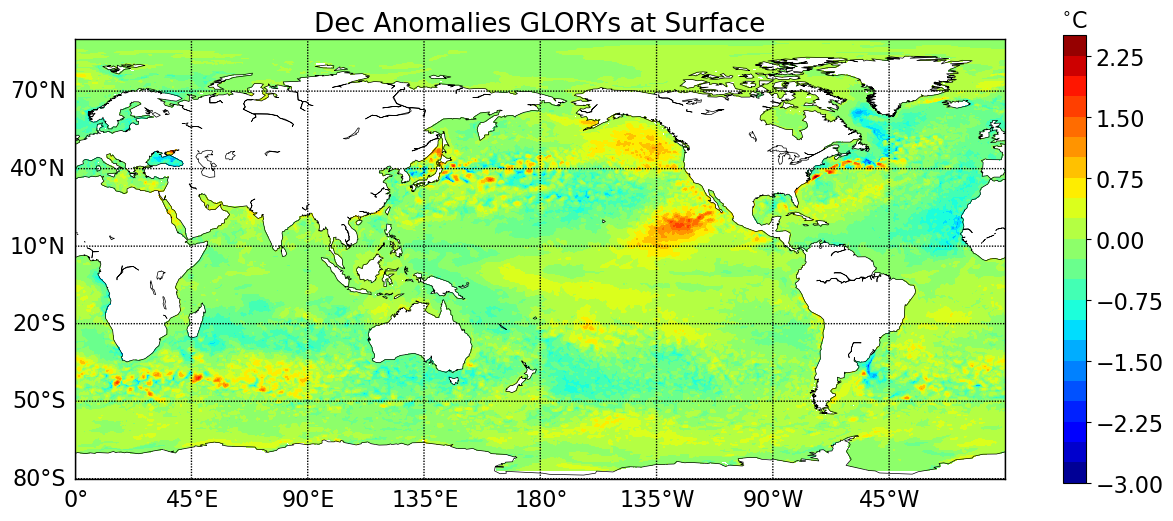

In [5]:
plot_variable(0, anom, 'Anomalies')


# Section 3:  Three month Avg
**You will need to have the anomalies computed already for each month used in the average**

In [19]:
#################################################################################################################
#################################################################################################################
# Function reads in raw cut anomalies
# directory changes for every month in a 3 month avg so a new function was rewritten 
# to compute climatologies 
# Input:
#         - anomalies_directory: string with anomaly directory
#           this changes for every month 
#         - year: int with the specific year to read
# Output:
#         - anom: 3D array of dim (depth, lat, lon) with the anomaly data
def read_anom_raw(anomalies_directory, year):
    fn   = month +'.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0 = ds(fn, 'r')
    anom = nc0.variables['anom'][:]
    anom = anom.filled()
    nc0.close()
    return anom

In [20]:
lat, lon, depths, _ = get_var(12)
years  = np.linspace(1994, 2021,29, dtype="int")                      # defining years for avg
month_indexes = [12,1,2]                                              # all winter months
save_directory = os.path.join('F:/GLORYS/Anomalies/Winter Avg') # saving to this folder 
create_folder(save_directory)                                         # create the folder if it doesn't exist 
for year in years: # iterate through years
    anom = np.zeros((len(depths),len(lat), len(lon)))
    for MON_INDEX in month_indexes:                                  # iterating through month index for every year
        month = months[MON_INDEX-1]                                  # using the right month name for the index
        anomalies_directory = os.path.join('F:/GLORYS/Anomalies/'+ month) # goint into correct monthly directory
        if MON_INDEX == 12:                                          # making sure to use the previous year for december
            anom += read_anom_raw(anomalies_directory, year-1)       # adding to running anom sum for the year
        else:
            anom += read_anom_raw(anomalies_directory, year)         # adding to running anom sum for the year
    anom = anom/3                                                    # avg anomalies
    # save anomalies
    fn   =  'Winter.anom.mon.'+str(year)+'.nc'                       # file name
    fn   = os.path.join(save_directory, fn)
    nc0  = ds(fn, 'w', format='NETCDF4')
    save_file(nc0, depths, lat, lon, anom, 'anom') # save winter average 

Folder 'F:/GLORYS/Anomalies/Winter Avg' created.


In [21]:
# This is for Standard deviation
lat, lon, depths, _ = get_var(12)
years  = np.linspace(1994, 2021,29, dtype="int")
month_indexes = [12,1,2]
save_directory = os.path.join('F:/GLORYS/Anomalies/Winter Avg') # saving to this folder 

weight = vol_weight(depths, lon, lat)
sdev = np.zeros((len(depths), len(lat),len(lon))) # initialize array 
for MON_INDEX in month_indexes:
    month = months[MON_INDEX-1]
    anomalies_directory     = os.path.join('F:/GLORYS/Anomalies/' + month)
    for year in years:
        if MON_INDEX == 12:
            anom = read_anom_raw(anomalies_directory, year-1)
            anom = anom/weight
            anom = anom**2
            sdev += anom
        else:
            anom = read_anom_raw(anomalies_directory, year)
            anom = anom/weight
            anom = anom**2
            sdev += anom
sdev = sdev/(len(years)*3)
sdev = np.sqrt(sdev)

fn   =  'Winter.mon.sdev.nc'
fn   = os.path.join(save_directory, fn)
nc0  = ds(fn, 'w', format='NETCDF4')
save_file(nc0, depths, lat, lon, sdev, 'sdev')

# Section 4: Three Month Running Clim and Anom

In [22]:
#################################################################################################################
#################################################################################################################
# Function
# 
# Input:
#         -
# Output:
#         -
# Important Variables:    
def compute_Clim_winter(month_indexes, years):
    clim = np.zeros((len(lat) * len(lon) * len(depths))) # initialize array for climatology
    time_total = 0
    for year in years:                            # iterate through every year
        if year == 1993:                          # only wand december of this year
            var  = read_raw_data(12,year)
            var  = var.flatten()            # flatten to more easily add grid points(could do without)
            clim    += var                     # sum of grid point through years
            time_total  +=1
        elif year == 2021:                        # only want Jan and Feb of this year
            var  = read_raw_data(1,year)         # read in January
            var  = var.flatten()            # flatten to more easily add grid points(could do without)
            clim    += var                     # sum of grid point through years
            var  = read_raw_data(2,year)         # read in Feburary 
            var  = var.flatten()            # flatten to more easily add grid points(could do without)
            clim    += var                     # sum of grid point through years
            time_total +=2
        else:
            for m in month_indexes:                   # iterate through season (3 months)
                var  = read_raw_data(m,year)         # read in 
                var  = var.flatten()            # flatten to more easily add grid points(could do without)
                clim    += var                     # sum of grid point through years
                time_total +=1
    clim = clim/time_total                            # divide by total amount of years for avg
    clim = np.reshape(clim, (len(depths),lat.shape[0], lon.shape[0])) # reshape to 3D array
    return clim
#################################################################################################################
#################################################################################################################
# Function
# 
# Input:
#         -
# Output:
#         -
# Important Variables:    
def compute_Clim_3month(month_indexes, years):
    clim = np.zeros((len(lat) * len(lon) * len(depths))) # initialize array for climatology
    time_total = 0
    for year in years:                            # iterate through every year
        for m in month_indexes:                   # iterate through season (3 months)
            var  = read_raw_data(m,year)         # read in 
            var  = var.flatten()            # flatten to more easily add grid points(could do without)
            clim    += var                     # sum of grid point through years
            time_total +=1
    clim = clim/time_total                            # divide by total amount of years for avg
    clim = np.reshape(clim, (len(depths),lat.shape[0], lon.shape[0])) # reshape to 3D array
    return clim

In [31]:
lat, lon, depths, years = get_var(1)

In [32]:
month_indexes = [1,2,12]
clim = compute_Clim_winter(month_indexes, years)

In [26]:
# saving climatologies
month = 'Winter'
fn =  month + '.mon.clim.nc'
anom_directory = 'F:/GLORYS/Anomalies/' + month
fn  = os.path.join(anom_directory, fn)
nc0 = ds(fn, 'w', format='NETCDF4')
save_file(nc0, depths, lat, lon, clim, 'clim')

In [35]:
#################################################################################################################
#################################################################################################################
# Function to compute anomalies and call save function
# Inputs:
#         - clim: a 3D array with climatology for all time 1993-2021
# Outputs:
#         - no specific output as the anomalies are saved to a file after calling save_file 
# Important variables:
#         - var: 3D array with ocean temperatures
def compute_anomalies_winter(month_indexes,clim):
    lat, lon, depths, years = get_var(1)       # get common variables for weights
    weight = vol_weight(depths, lon, lat)     # volume weight
    ind = 0
    for year in years:                 # for every year
        if year == 1993:                          # only want december of this year
            var  = read_raw_data(12,year)
            anom = var - clim
            anom = anom * weight
            fn   =  month + '.anom.mon.'+str(ind)+'.nc'
            fn   = os.path.join(anom_directory, fn)
            nc0  = ds(fn, 'w', format='NETCDF4')
            save_file(nc0, depths, lat, lon, anom, 'anom')
            ind  += 1
        elif year == 2021:                        # only want Jan and Feb of this year
            var  = read_raw_data(1,year)         # read in January
            anom = var - clim
            anom = anom * weight
            fn   =  month + '.anom.mon.'+str(ind)+'.nc'
            fn   = os.path.join(anom_directory, fn)
            nc0  = ds(fn, 'w', format='NETCDF4')
            save_file(nc0, depths, lat, lon, anom, 'anom')
            ind  += 1 
            var  = read_raw_data(2,year)         # read in Feb
            anom = var - clim
            anom = anom * weight
            fn   =  month + '.anom.mon.'+str(ind)+'.nc'
            fn   = os.path.join(anom_directory, fn)
            nc0  = ds(fn, 'w', format='NETCDF4')
            save_file(nc0, depths, lat, lon, anom, 'anom')
            ind  += 1 
        else:
            for m in month_indexes:                   # iterate through season (3 months)
                var  = read_raw_data(m,year)           # read in raw temp data for specified year
                anom = var - clim
                anom = anom * weight
                fn   =  month + '.anom.mon.'+str(ind)+'.nc'
                fn   = os.path.join(anom_directory, fn)
                nc0  = ds(fn, 'w', format='NETCDF4')
                save_file(nc0, depths, lat, lon, anom, 'anom')
                ind  += 1 

In [36]:
compute_anomalies_winter(month_indexes,clim)

In [37]:
import time
start = time.time()
year = 1993
fn = 'F:/GLORYS/Anomalies/' + month + '/'+ month +'.anom.mon.'+str(year)+'.nc'
nc0 = ds(fn, 'r')
anom_tprime = nc0.variables['anom'][:]
anom_tprime = anom_tprime.compressed() # flatttentens and gets rid of NaN
nc0.close()
end = time.time()
print(end - start)

FileNotFoundError: [Errno 2] No such file or directory: 'F:/GLORYS/Anomalies/Winter/Winter.anom.mon.1993.nc'